In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import xesmf as xe
import matplotlib.pyplot as plt

# Computing weights (global and ocean only)

In [5]:
PATH_jra = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_JRA.TL319_t232.time_varying_HadOIBl_upd_swdn/cpl/hist/'
PATH_raw = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_JRA55raw.TL319_t232.time_varying_HadOIBl/cpl/hist/'
PATH_era = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_1990_1999/cpl/hist/'

filename_jra = 'a.e30.A_JRA.TL319_t232.time_varying_HadOIBl_upd_swdn.cpl.hi.1959-12-31-81000.nc'
filename_raw = 'a.e30.A_JRA55raw.TL319_t232.time_varying_HadOIBl.cpl.hi.1961-01-01-00000.nc'
filename_era = 'a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_1990_1999.cpl.hi.2000-01-01-00000.nc'

lat_ocn_jra = xr.open_dataset(PATH_jra + filename_jra, engine="netcdf4")['ocnExp_lat'].isel(time=0, drop = True).rename({"ocnExp_ny": "y", "ocnExp_nx": "x"})
lat_ocn_raw = xr.open_dataset(PATH_raw + filename_raw, engine="netcdf4")['ocnExp_lat'].isel(time=0, drop = True).rename({"ocnExp_ny": "y", "ocnExp_nx": "x"})
lat_ocn_era = xr.open_dataset(PATH_era + filename_era, engine="netcdf4")['ocnExp_lat'].isel(time=0, drop = True).rename({"ocnExp_ny": "y", "ocnExp_nx": "x"})

mask_ocn_jra = xr.open_dataset(PATH_jra + filename_jra, engine="netcdf4")['ocnImp_So_omask'].isel(time=0, drop = True).rename({"ocnImp_ny": "y", "ocnImp_nx": "x"})
mask_ocn_raw = xr.open_dataset(PATH_raw + filename_raw, engine="netcdf4")['ocnImp_So_omask'].isel(time=0, drop = True).rename({"ocnImp_ny": "y", "ocnImp_nx": "x"})
mask_ocn_era = xr.open_dataset(PATH_era + filename_era, engine="netcdf4")['ocnImp_So_omask'].isel(time=0, drop = True).rename({"ocnImp_ny": "y", "ocnImp_nx": "x"})

In [15]:
ls /glade/derecho/scratch/mmarkina/archive/a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_1990_1999/cpl/hist/a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_1990_1999.cpl.hi.2000-01-01-00000.nc

/glade/derecho/scratch/mmarkina/archive/a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_1990_1999/cpl/hist/a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_1990_1999.cpl.hi.2000-01-01-00000.nc


In [6]:
weights_ocn_jra = np.cos(np.deg2rad(lat_ocn_jra))*mask_ocn_jra
weights_ocn_jra = weights_ocn_jra / weights_ocn_jra.sum()  # Normalize so they sum to 1

weights_ocn_raw = np.cos(np.deg2rad(lat_ocn_raw))*mask_ocn_raw
weights_ocn_raw = weights_ocn_raw / weights_ocn_raw.sum()  # Normalize so they sum to 1

weights_ocn_era = np.cos(np.deg2rad(lat_ocn_era))*mask_ocn_era
weights_ocn_era = weights_ocn_era / weights_ocn_era.sum()  # Normalize so they sum to 1
# weights_ocn_era.plot()
# weights_ocn_era.sum()

# Converting JRA ocnExp mask into atmImp mask

In [7]:
def convert_ocnExp_to_atmImp_mask(PATH, filename):
    '''
    PATH - path to raw model output files 
    filename - filename of one of these files (to read coords of ocnExp and atmImp)
    '''
    lat_in = xr.open_dataset(PATH + filename)['ocnExp_lat'].isel(time=0, drop = True)
    lon_in = xr.open_dataset(PATH + filename)['ocnExp_lon'].isel(time=0, drop = True) % 360

    mask = xr.open_dataset(PATH + filename, engine="netcdf4")['ocnImp_So_omask'].isel(time=0, drop = True).rename({"ocnImp_ny": "ocnExp_ny", "ocnImp_nx": "ocnExp_nx"})
    
    mask_in = xr.DataArray(mask.values, dims=("y", "x"),
                           coords={"lon": (("y", "x"), lon_in.values), "lat": (("y", "x"), lat_in.values)},
                           name="mask")
    
    
    lat_out = xr.open_dataset(PATH + filename)['atmImp_lat'].isel(time=0, drop = True)
    lon_out = xr.open_dataset(PATH + filename)['atmImp_lon'].isel(time=0, drop = True)
    
    # Create xESMF regridder for curvilinear grid
    grid_in = xr.Dataset({"lat": (("y", "x"), lat_in.values), "lon": (("y", "x"), lon_in.values)})
    grid_out = xr.Dataset({"lat": (("y", "x"), lat_out.values), "lon": (("y", "x"), lon_out.values)})
    
    regridder = xe.Regridder(grid_in, grid_out, "nearest_s2d")  # 'nearest_s2d' is best for masks
    
    # Apply regridding
    mask_out = regridder(mask_in)
    mask_out = mask_out.rename("mask")  # Explicitly set the name

    mask_out_da = xr.DataArray(mask_out.values, dims=("y", "x"),
                       coords={"lon": (("y", "x"), lon_out.values), "lat": (("y", "x"), lat_out.values)},
                       name="mask")


    return mask_out_da

In [8]:
mask_atm_jra = convert_ocnExp_to_atmImp_mask(PATH_jra, filename_jra)
mask_atm_raw = convert_ocnExp_to_atmImp_mask(PATH_raw, filename_raw)
mask_atm_era = convert_ocnExp_to_atmImp_mask(PATH_era, filename_era)

In [9]:
lat_atm_jra = mask_atm_jra.lat
lat_atm_raw = mask_atm_raw.lat
lat_atm_era = mask_atm_era.lat

weights_atm_jra = np.cos(np.deg2rad(lat_atm_jra))*mask_atm_jra
weights_atm_jra = weights_atm_jra / weights_atm_jra.sum()  # Normalize so they sum to 1

weights_atm_raw = np.cos(np.deg2rad(lat_atm_raw))*mask_atm_raw
weights_atm_raw = weights_atm_raw / weights_atm_raw.sum()  # Normalize so they sum to 1

weights_atm_era = np.cos(np.deg2rad(lat_atm_era))*mask_atm_era
weights_atm_era = weights_atm_era / weights_atm_era.sum()  # Normalize so they sum to 1


# Plotting means from the output 

In [10]:
EXPERIMENT_JRA = "a.e30.A_JRA.TL319_t232.daily_SST_ERA5"
EXPERIMENT_RAW = "a.e30.A_JRA55raw.TL319_t232.daily_SST_ERA5"
EXPERIMENT_ERA = "a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_all" 

JRA_YEARS = "1959_2019"
RAW_YEARS = "1959_2019"
ERA_YEARS = "1959_2019"


PATH_JRA = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/" + EXPERIMENT_JRA + "/MONTHLY/" 
PATH_RAW = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/" + EXPERIMENT_RAW + "/MONTHLY/"  
PATH_ERA = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/" + EXPERIMENT_ERA + "/MONTHLY/"  

file_names_ocn_jra = {
    "lwnet": "lwnet_" + JRA_YEARS + ".nc",
    "latent": "latent_" + JRA_YEARS + ".nc",
    "sensible": "sensible_" + JRA_YEARS + ".nc",
}

file_names_ocn_raw = {
    "lwnet": "lwnet_" + RAW_YEARS + ".nc",
    "latent": "latent_" + RAW_YEARS + ".nc",
    "sensible": "sensible_" + RAW_YEARS + ".nc",
}

file_names_ocn_era = {
    "lwnet": "lwnet_" + ERA_YEARS + ".nc",
    "latent": "latent_" + ERA_YEARS + ".nc",
    "sensible": "sensible_" + ERA_YEARS + ".nc",
}


file_names_atm_jra = {
    "atm_swnet": "atm_swnet_" + JRA_YEARS + ".nc",
}

file_names_atm_raw = {
    "atm_swnet": "atm_swnet_" + RAW_YEARS + ".nc",
}

file_names_atm_era = {
    "atm_swnet": "atm_swnet_" + ERA_YEARS + ".nc",
}

In [11]:
%%time


def process_dataset(path, file_names, weights, variable_names, var_type):
    print(path)
    yearly_means = {}
    for key, file_name in file_names.items():

        if var_type == 'ocn':
            ds = xr.open_dataset(path + file_name, engine="netcdf4").rename({"ocnExp_nx": "x", "ocnExp_ny": "y"})
        elif var_type == 'atm':
            ds = xr.open_dataset(path + file_name, engine="netcdf4").rename({"atmImp_nx": "x", "atmImp_ny": "y"})
            
        var_name = variable_names[key]

        weights_br = weights.broadcast_like(ds[var_name])  # Ensure shape matches the data variable
        nan_counts = weights_br.isnull().sum()
        print(nan_counts)

        var_time_series = ds[var_name].weighted(weights_br).mean(dim=["x", "y"])
        var_time_series["time"] = pd.to_datetime([t.strftime('%Y-%m-%d') for t in var_time_series["time"].values])
        yearly_mean = var_time_series.resample(time="1YE").mean()
        yearly_means[key] = yearly_mean

        del weights_br
        
    yearly_means["sum"] = sum(yearly_means.values())
    return yearly_means



variable_names_ocn = {
    # "swnet": "ocnExp_Foxx_swnet",
    "lwnet": "ocnExp_Foxx_lwnet",
    "latent": "ocnExp_Foxx_lat",
    "sensible": "ocnExp_Foxx_sen",
}

variable_names_atm = {
    "atm_swnet": "atmImp_Faxa_swnet"
}


# Process all datasets
yearly_means_ocn_jra = process_dataset(PATH_JRA, file_names_ocn_jra, weights_ocn_jra, variable_names_ocn, var_type = 'ocn')
yearly_means_ocn_raw = process_dataset(PATH_RAW, file_names_ocn_raw, weights_ocn_raw, variable_names_ocn, var_type = 'ocn')
yearly_means_ocn_era = process_dataset(PATH_ERA, file_names_ocn_era, weights_ocn_era, variable_names_ocn, var_type = 'ocn')

yearly_means_atm_jra = process_dataset(PATH_JRA, file_names_atm_jra, weights_atm_jra, variable_names_atm, var_type = 'atm')
yearly_means_atm_raw = process_dataset(PATH_RAW, file_names_atm_raw, weights_atm_raw, variable_names_atm, var_type = 'atm')
yearly_means_atm_era = process_dataset(PATH_ERA, file_names_atm_era, weights_atm_era, variable_names_atm, var_type = 'atm')

/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA.TL319_t232.daily_SST_ERA5/MONTHLY/
<xarray.DataArray ()> Size: 8B
array(0)
<xarray.DataArray ()> Size: 8B
array(0)
<xarray.DataArray ()> Size: 8B
array(0)
/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55raw.TL319_t232.daily_SST_ERA5/MONTHLY/
<xarray.DataArray ()> Size: 8B
array(0)
<xarray.DataArray ()> Size: 8B
array(0)
<xarray.DataArray ()> Size: 8B
array(0)
/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_all/MONTHLY/
<xarray.DataArray ()> Size: 8B
array(0)
<xarray.DataArray ()> Size: 8B
array(0)
<xarray.DataArray ()> Size: 8B
array(0)
/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA.TL319_t232.daily_SST_ERA5/MONTHLY/
<xarray.DataArray ()> Size: 8B
array(0)
/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55raw.TL319_t232.daily_SST_ERA5/MONTHLY/
<xarray.DataArray ()> Size: 8B
array(0)
/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_ERA5.TL319_t23

In [12]:
ds_jra = xr.Dataset()
ds_jra['swnet'] = yearly_means_atm_jra['atm_swnet']
ds_jra['lwnet'] = yearly_means_ocn_jra['lwnet']
ds_jra['latent'] = yearly_means_ocn_jra['latent']
ds_jra['sensible'] = yearly_means_ocn_jra['sensible']
ds_jra['total'] = ds_jra['swnet'] + ds_jra['lwnet'] + ds_jra['latent'] + ds_jra['sensible']

ds_raw = xr.Dataset()
ds_raw['swnet'] = yearly_means_atm_raw['atm_swnet']
ds_raw['lwnet'] = yearly_means_ocn_raw['lwnet']
ds_raw['latent'] = yearly_means_ocn_raw['latent']
ds_raw['sensible'] = yearly_means_ocn_raw['sensible']
ds_raw['total'] = ds_raw['swnet'] + ds_raw['lwnet'] + ds_raw['latent'] + ds_raw['sensible']

ds_era = xr.Dataset()
ds_era['swnet'] = yearly_means_atm_era['atm_swnet']
ds_era['lwnet'] = yearly_means_ocn_era['lwnet']
ds_era['latent'] = yearly_means_ocn_era['latent']
ds_era['sensible'] = yearly_means_ocn_era['sensible']
ds_era['total'] = ds_era['swnet'] + ds_era['lwnet'] + ds_era['latent'] + ds_era['sensible']

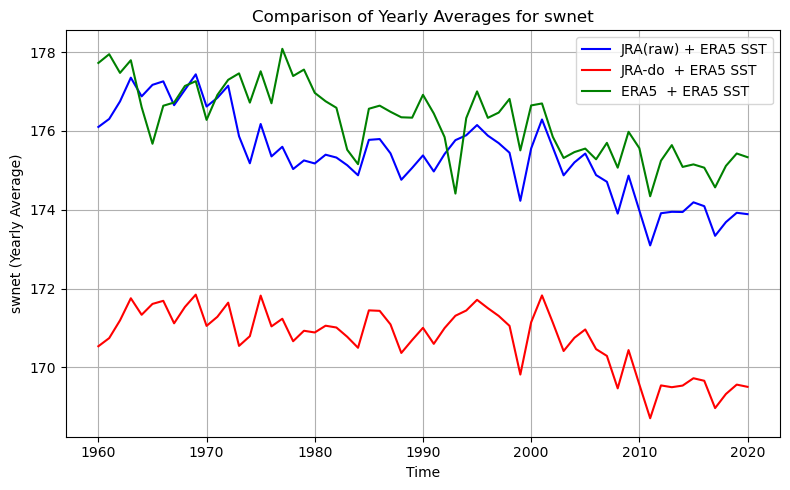

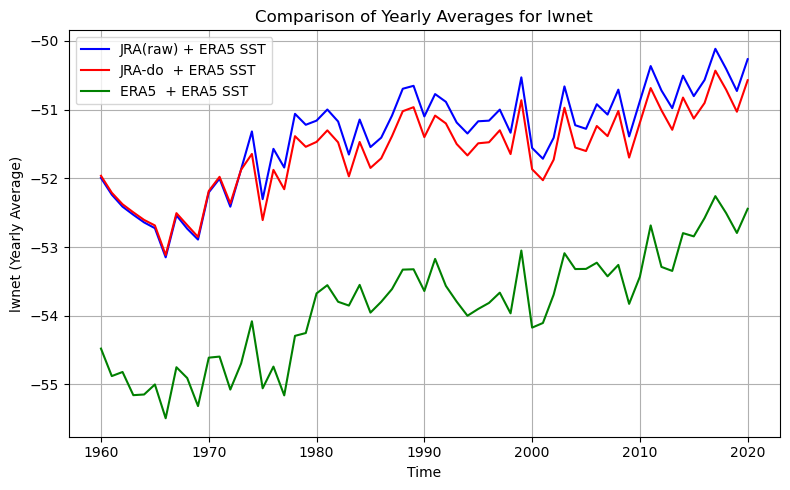

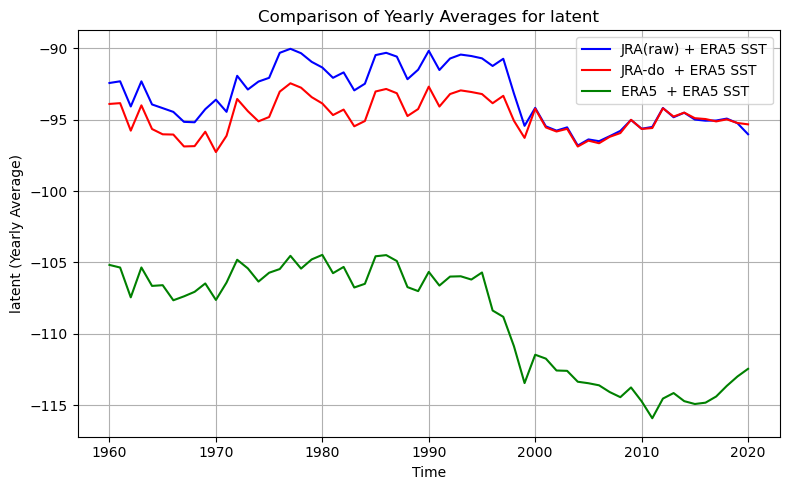

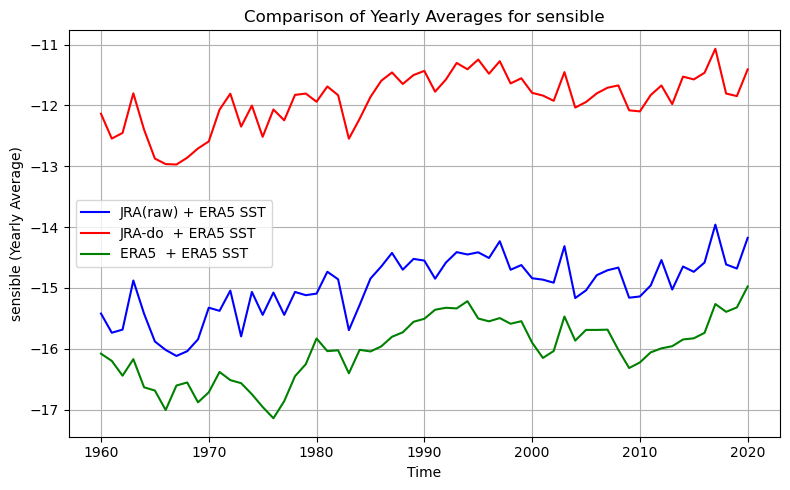

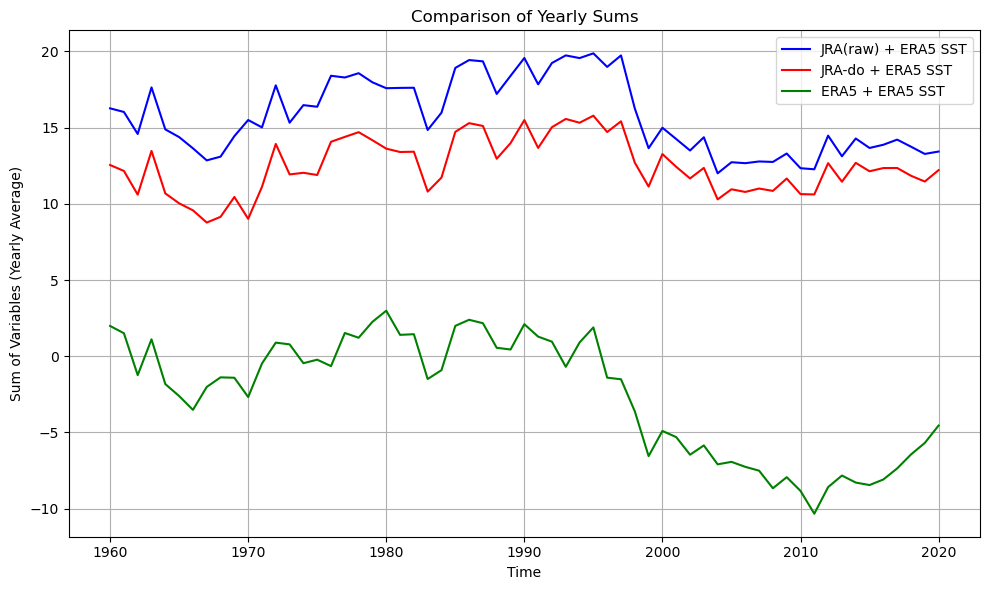

In [13]:
var_names = ['swnet', 'lwnet', 'latent', 'sensible']

# Plot comparison for each variable
for key in var_names:
    plt.figure(figsize=(8, 5))
    plt.plot(ds_raw[key]["time"], ds_raw[key], label=f"JRA(raw) + ERA5 SST", c = 'b')
    plt.plot(ds_jra[key]["time"], ds_jra[key], label=f"JRA-do  + ERA5 SST", c = 'r')
    plt.plot(ds_era[key]["time"], ds_era[key], label=f"ERA5  + ERA5 SST", c = 'g')
    plt.xlabel("Time")
    plt.ylabel(f"{key} (Yearly Average)")
    plt.title(f"Comparison of Yearly Averages for {key}")
    # plt.xlim(1940,2020) 
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()




# Plot comparison for the sum of variables
plt.figure(figsize=(10, 6))
plt.plot(ds_raw["time"], ds_raw["total"], label="JRA(raw) + ERA5 SST", c = 'b')
plt.plot(ds_jra["time"], ds_jra["total"], label="JRA-do + ERA5 SST", c = 'r')
plt.plot(ds_era["time"], ds_era["total"], label="ERA5 + ERA5 SST", c = 'g')
plt.xlabel("Time")
# plt.xlim(1940, 2020) 
plt.ylabel("Sum of Variables (Yearly Average)")
plt.title("Comparison of Yearly Sums")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()